# Covid-19, bakteriális és vírusos pneumonia elkülönítése mellkasröntgen felvételek alapján

*Neurális hálózat alapú szegmentációs és klasszifikációs modell építése*

*Ambrus Csaba*



## 0. Setup

In [12]:
from pathlib import Path
import os

BRANCH = "main"
REPO_URL = "https://github.com/csambrus/CXR.git"
REPO_DIR = "/content/CXR"

if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")

%cd /content
if not os.path.exists(f"{REPO_DIR}/.git"):
    !git clone --branch {BRANCH} --single-branch {REPO_URL} {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git fetch origin {BRANCH}
    !git checkout {BRANCH}
    !git pull origin {BRANCH}

%cd {REPO_DIR}
%pip install -r requirements.txt

!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

from src.runtime import setup_tensorflow_runtime

setup_tensorflow_runtime()


/content
/content/CXR
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 4.93 KiB | 2.00 KiB/s, done.
From https://github.com/csambrus/CXR
 * branch            main       -> FETCH_HEAD
   fb9d1fe..1432112  main       -> origin/main
Already on 'main'
Your branch is behind 'origin/main' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
From https://github.com/csambrus/CXR
 * branch            main       -> FETCH_HEAD
Updating fb9d1fe..1432112
Fast-forward
 notebooks/CXR_20260512.ipynb |  37 +++--
 notebooks/CXR_20260514.ipynb | 347 ++++++++++---------------------------------
 src/lung_segmentation.py     | 115 ++++++++++----
 3 files changed, 187 insertions(+), 312 deletions(-)
/content/CXR
TF version: 2.20.0
GPUs:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='

12

# 1. Adatok betöltése

In [13]:
from pathlib import Path
from src.download_dataset import download_all_datasets

from src.config import (
    SEGMENTATION_RAW_DIR,
    SEGMENTATION_DATA_DIR,
)

# True: törli a .dataset_ready markereket és (Colabon) a Drive-os zip + régi mappa-cache-t is,
# majd a Kaggle-ről tiszta lappal tölt újra. Normál futáshoz állítsd False-ra.
FORCE_FRESH_DATASET_DOWNLOAD = False

print("SEGMENTATION_RAW_DIR:", SEGMENTATION_RAW_DIR)
print("SEGMENTATION_DATA_DIR:", SEGMENTATION_DATA_DIR)

download_all_datasets(force=FORCE_FRESH_DATASET_DOWNLOAD)


SEGMENTATION_RAW_DIR: /content/CXR/data/segment_raw
SEGMENTATION_DATA_DIR: /content/CXR/data/interim/segmentation
[SKIP] Classifier dataset already exists, no download needed.
[SKIP] Segmentation dataset already exists, no download needed.


# 2. Szegmentáció

Ebben a blokkban fut a teljes szegmentacios pipeline:

- szegmentacios adatellenorzes,
- tanitas es kiertes,
- predikcios mintak,
- classifier variansok generalasa.

A `generate_classifier_variants()` a futas vegen **grafikus osszefoglalot** is ment (`data/interim/segmentation/classifier_variants_figs/classifier_variants_section2_summary.png`), igy a 2. szakasz eredmenyei egy helyen attekinthetoek.


In [14]:
from src.lung_segmentation import prepare_segmentation_dataset, verify_png_files

verify_png_files(SEGMENTATION_RAW_DIR / "images", "Images")
verify_png_files(SEGMENTATION_RAW_DIR / "masks", "Masks")
prepare_segmentation_dataset(overwrite = False)

Images: checked 3311 files, bad=0
Masks: checked 3311 files, bad=0
PREPARE SEGMENTATION DATASET
raw_images_dir   : /content/CXR/data/segment_raw/images
raw_masks_dir    : /content/CXR/data/segment_raw/masks
merged_images_dir: /content/CXR/data/interim/segmentation/images
merged_masks_dir : /content/CXR/data/interim/segmentation/masks
num_images_found : 3311
overwrite        : False
show_every       : 250


Preparing pairs:   0%|          | 0/3311 [00:00<?, ?img/s]


[OK] Prepared segmentation dataset
images found       : 3311
pairs saved        : 0
missing masks      : 0
skipped validation : 0
skipped existing   : 3311
read errors        : 0
elapsed            : 0.15 sec
speed              : 22235.43 img/s


0

[SKIP] Segmentation splits already exist.
[INFO] Existing split summary: {'train': 2317, 'val': 497, 'test': 497, 'total_valid_pairs': 3311, 'total_images_found': 3311, 'missing_masks': 0, 'seed': 42, 'val_ratio': 0.15, 'test_ratio': 0.15, 'overwrite': False, 'require_masks': True, 'train_csv': '/content/CXR/data/interim/segment_splits/train.csv', 'val_csv': '/content/CXR/data/interim/segment_splits/val.csv', 'test_csv': '/content/CXR/data/interim/segment_splits/test.csv', 'invalid_examples': []}
[SKIP] Lung segmentation training already exists and split is unchanged.
model_dir      : /content/CXR/data/interim/segment_models/lung_unet
best_model     : /content/CXR/data/interim/segment_models/lung_unet/best_model.keras
history        : /content/CXR/data/interim/segment_models/lung_unet/history.csv
run_metadata   : /content/CXR/data/interim/segment_models/lung_unet/run_metadata.json
[INFO] Saved: /content/CXR/data/interim/segment_models/lung_unet/training_curves/epoch_loss.png


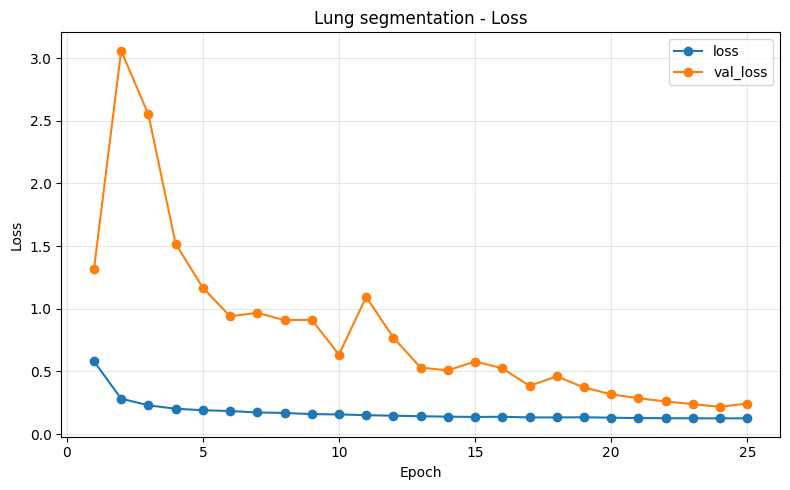

[INFO] Saved: /content/CXR/data/interim/segment_models/lung_unet/training_curves/epoch_dice_coef.png


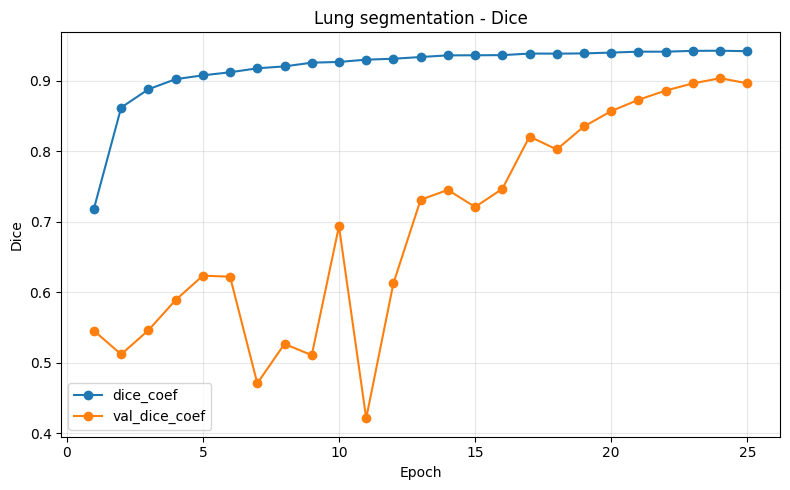

[INFO] Saved: /content/CXR/data/interim/segment_models/lung_unet/training_curves/epoch_iou_coef.png


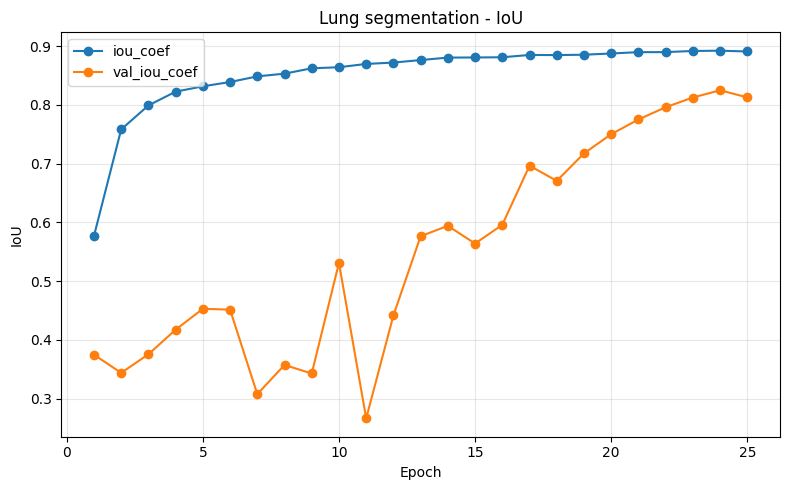

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 681ms/step - dice_coef: 0.9037 - iou_coef: 0.8243 - loss: 0.2187
[OK] Segmentation test metrics: {'loss': 0.21873913705348969, 'compile_metrics': 0.9037091732025146}


{'loss': 0.21873913705348969, 'compile_metrics': 0.9037091732025146}

In [15]:
from src.lung_segmentation import create_splits, train_segmentation, evaluate_segmentation

create_splits()
train_segmentation(epochs=25)
evaluate_segmentation()

[INFO] Saved: /content/CXR/data/interim/segment_models/lung_unet/training_history.png


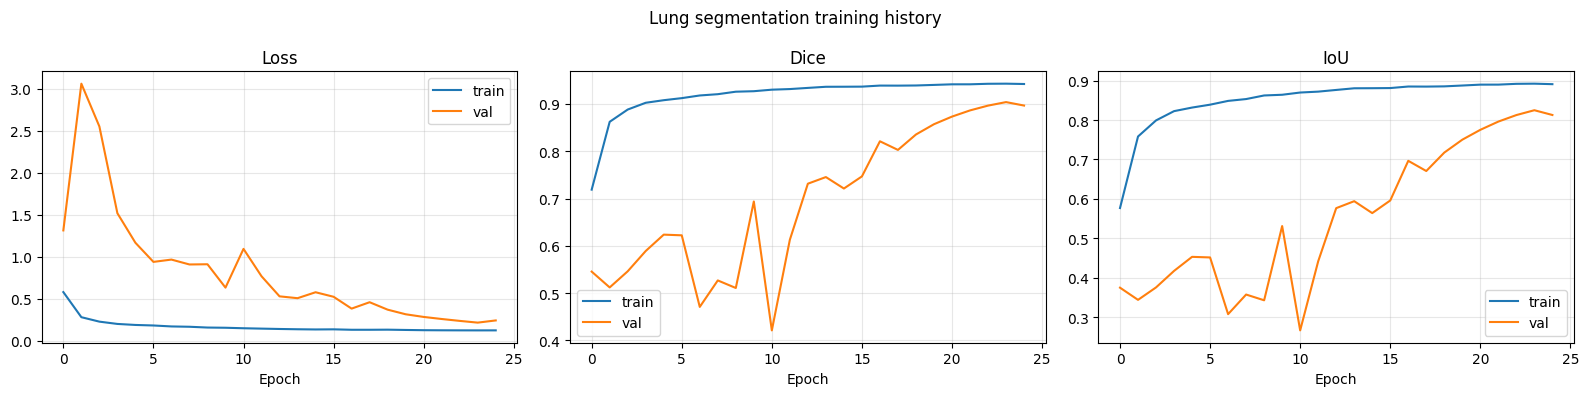

[INFO] Saved: /content/CXR/data/interim/segment_models/lung_unet/prediction_examples.png


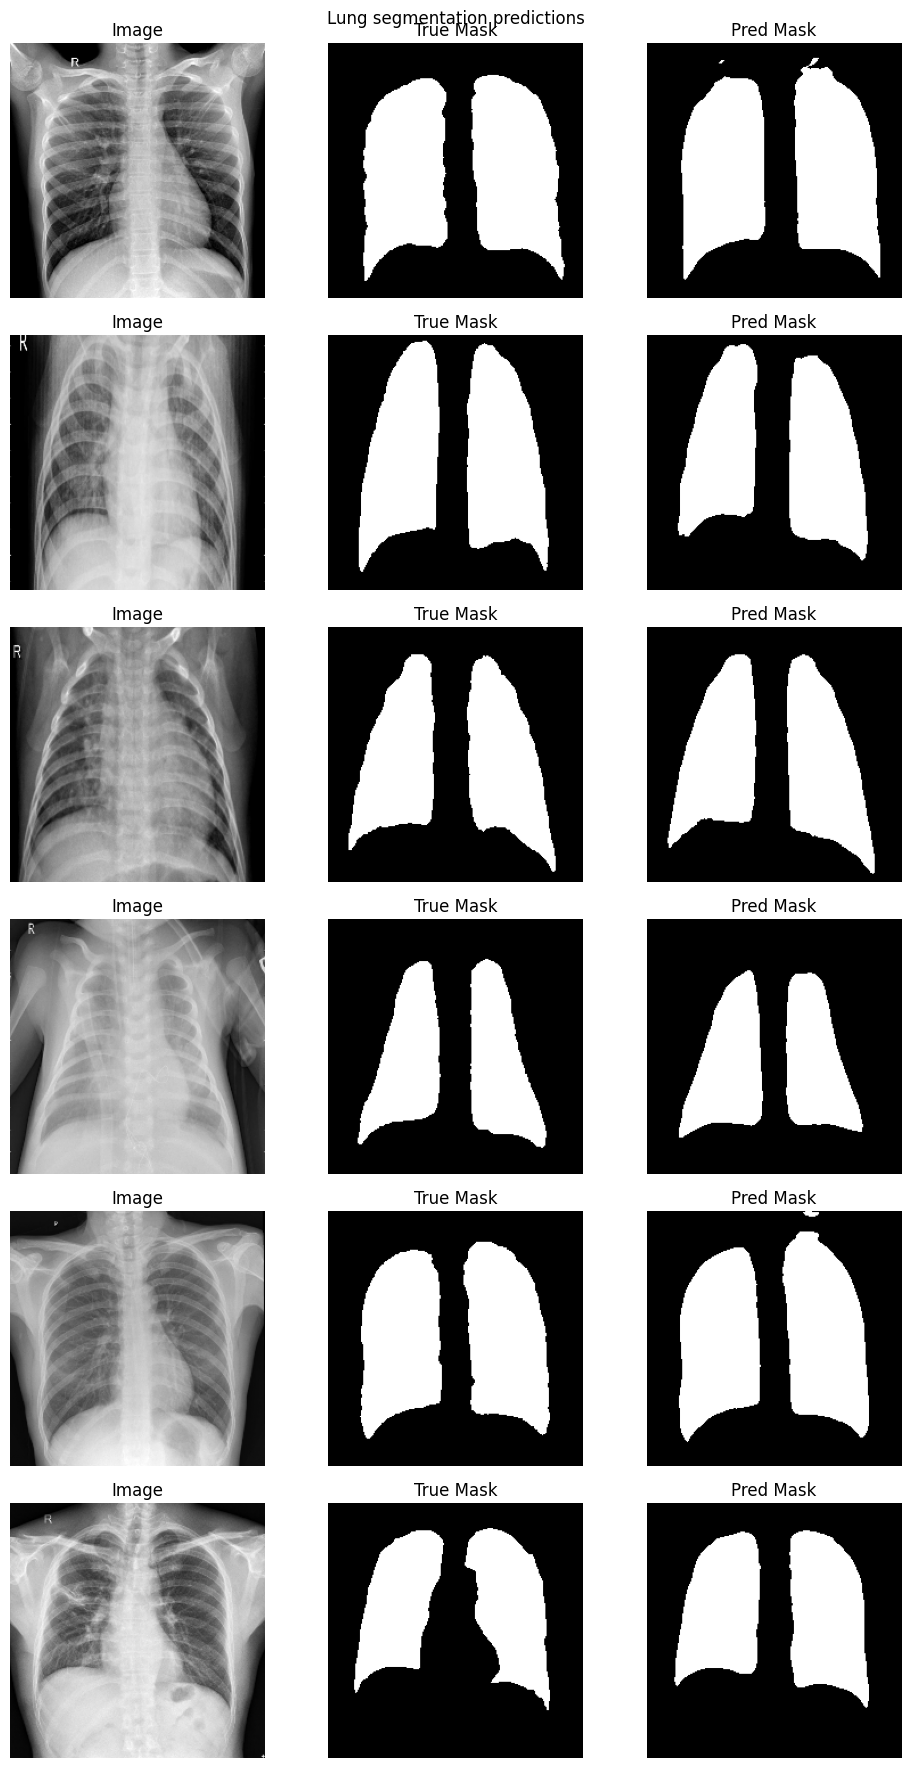

PosixPath('/content/CXR/data/interim/segment_models/lung_unet/prediction_examples.png')

In [16]:
from src.lung_segmentation import plot_training_history, plot_predictions

plot_training_history()
plot_predictions()

GENERATE CLASSIFIER VARIANTS
(lung_masks, lung_masked, lung_crop)
source_root   : /content/CXR/data/raw
num_images    : 9208
threshold     : 0.5
crop_margin   : 10
overwrite     : False
show_every    : 250


Generating classifier variants:   0%|          | 0/9208 [00:00<?, ?img/s]

[INFO] Összefoglaló ábra: /content/CXR/data/interim/segmentation/classifier_variants_figs/classifier_variants_section2_summary.png

[OK] Generated classifier variants
images found       : 9208
newly saved        : 0
skipped existing   : 9208
errors             : 0
lung_mask_dir      : /content/CXR/data/interim/segmentation/lung_masks
lung_masked_dir    : /content/CXR/data/interim/segmentation/lung_masked
lung_crop_dir      : /content/CXR/data/interim/segmentation/lung_crop
elapsed            : 0.74 sec
speed              : 12490.50 img/s


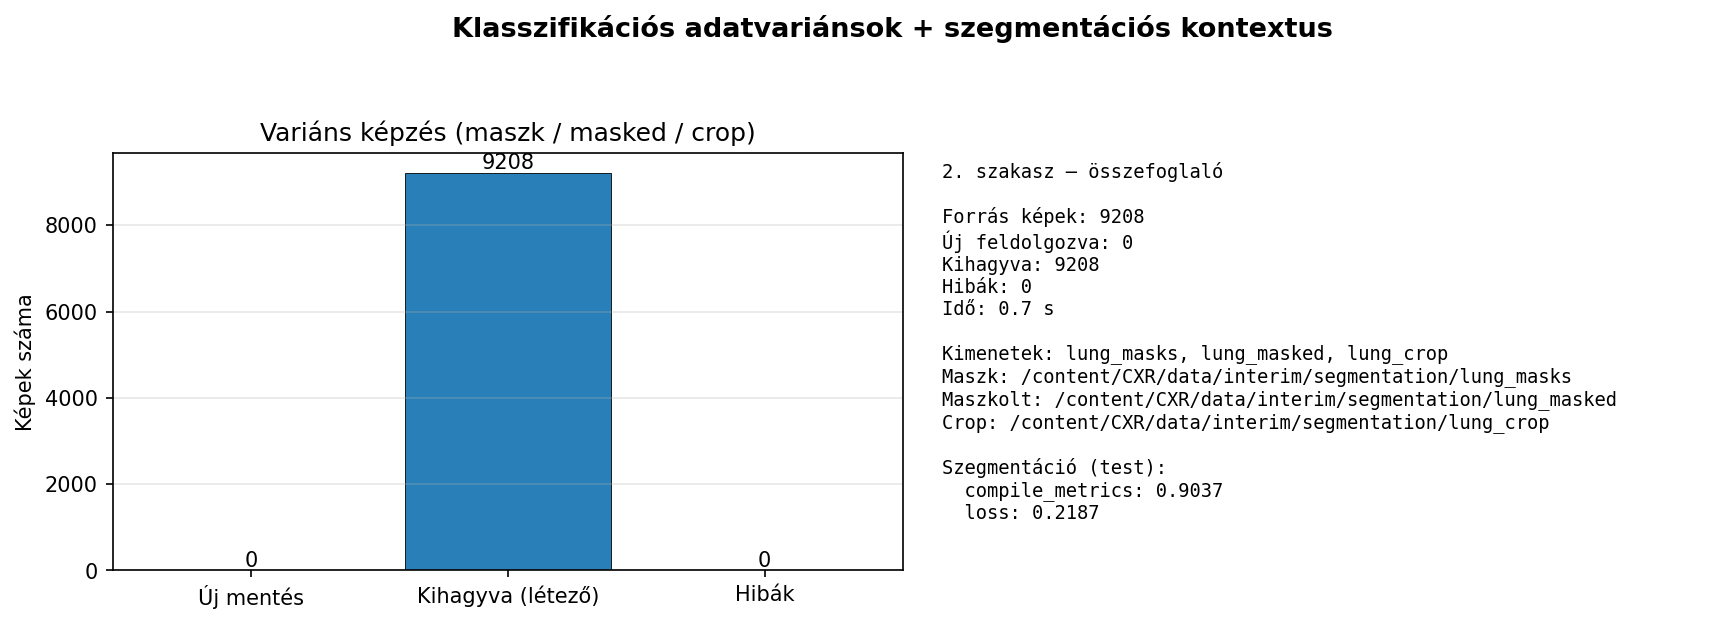

In [17]:
from pathlib import Path

from IPython.display import Image, display

from src.lung_segmentation import generate_classifier_variants

variant_summary = generate_classifier_variants()
fig_path = variant_summary.get("summary_figure_path")
if fig_path and Path(fig_path).exists():
    display(Image(filename=fig_path))


# 3. Klasszifikáció

Ebben a blokkban fut a klasszifikacios pipeline a split ellenorzestol a vegso leaderboardig.


In [18]:
import pandas as pd
from pathlib import Path

from src.config import (
    RAW_DIR,
    LUNG_MASKED_DIR,
    LUNG_CROP_DIR,
    MODELS_DIR,
    SPLITS_DIR,
    OUTPUT_DIR,
    ensure_dir,
)
from src.dataloader import print_split_summary
from src.compare_explainability import run_compare_explainability
from src.pipeline import (
    get_default_model_run_configs,
    run_training_pipeline,
    build_final_comparison,
    generate_final_plots,
    report_best_models,
    print_pipeline_leaderboard,
    save_pipeline_config,
)

RUN_FULL_RETRAIN = True

DATA_VARIANTS = ["raw", "lung_crop", "lung_masked"]  # raw, crop, masked
FINAL_COMPARISON_NAME = "project_final_optimized"
FINAL_OUT_DIR = ensure_dir(Path(MODELS_DIR) / FINAL_COMPARISON_NAME)

print("RAW_DIR        :", RAW_DIR)
print("LUNG_MASKED_DIR:", LUNG_MASKED_DIR)
print("LUNG_CROP_DIR  :", LUNG_CROP_DIR)
print("MODELS_DIR     :", MODELS_DIR)
print("SPLITS_DIR     :", SPLITS_DIR)
print("OUTPUT_DIR     :", OUTPUT_DIR)
print("FINAL_OUT_DIR  :", FINAL_OUT_DIR)


RAW_DIR        : /content/CXR/data/raw
LUNG_MASKED_DIR: /content/CXR/data/interim/segmentation/lung_masked
LUNG_CROP_DIR  : /content/CXR/data/interim/segmentation/lung_crop
MODELS_DIR     : /content/CXR/data/interim/models
SPLITS_DIR     : /content/CXR/data/interim/splits
OUTPUT_DIR     : /content/CXR/outputs
FINAL_OUT_DIR  : /content/CXR/data/interim/models/project_final_optimized


## 3.1 Split-ek képzése: train / valid / test: 70% / 15% / 15%

Itt ellenorizzuk, hogy a `raw`, `lung_masked` es `lung_crop` variansok ugyanazt a split logikat kovetik.

Ez biztositja, hogy a modell- es variansosszehasonlitas fair maradjon.

In [19]:
from src.dataloader import create_splits, print_split_summary
from src.config import RAW_DIR, SPLITS_DIR
from pathlib import Path

# Convert RAW_DIR and SPLITS_DIR to Path objects if they are strings
source_root_path = Path(RAW_DIR)
split_dir_path = Path(SPLITS_DIR)

splits = create_splits(
    source_root=source_root_path,
    split_dir=split_dir_path,
    overwrite=True,
)

print_split_summary(split_dir_path)


[INFO] CLASS_INFOS mapping:
 label           class_key          class_name             raw_dir
     0              normal              Normal              Normal
     1     pneumonia_viral     Pneumonia-Viral     Pneumonia-Viral
     2 pneumonia_bacterial Pneumonia-Bacterial Pneumonia-Bacterial
     3             covid19            COVID-19            COVID-19

[OK] Created split CSV files:
train: /content/CXR/data/interim/splits/train.csv 6445
val  : /content/CXR/data/interim/splits/val.csv 1381
test : /content/CXR/data/interim/splits/test.csv 1382

Train class distribution
------------------------------------------------------------------------
 0 | normal                 | Normal                 |   2289 |  35.52%
 1 | pneumonia_viral        | Pneumonia-Viral        |   1159 |  17.98%
 2 | pneumonia_bacterial    | Pneumonia-Bacterial    |   2100 |  32.58%
 3 | covid19                | COVID-19               |    897 |  13.92%
---------------------------------------------------------

## 3.2 Transfer modellek: ImageNet súlyok letöltése + build ellenőrzés

A **ResNet50**, **VGG16** és **EfficientNetB0** ImageNet-súlyai a `train.build_model(..., pretrained=True)` híváskor kerülnek a **Keras cache**-be (tipikusan `~/.keras/models/`). Ha csak egy modellt építenél fel itt, a többi súlya csak később, a saját training futásánál töltődne le először.

Ez a cella **mindhárom transfer modellt** egyszer felépíti: így a súlyok már a lemezen vannak a hosszabb 3.4-es training előtt, és mindegyiknél ellenőrizzük a `scale_to_255` réteget (EfficientNet / ResNet / VGG pipeline).

A **baseline_cnn** nem ImageNet előtanítású — azt a training építi fel, itt nem kell letölteni.


In [20]:
from src.train import build_model

# Mindhárom transfer modell: ImageNet súlyok első letöltése ide esik (ha még nincs cache).
_TRANSFER_MODELS = ("efficientnetb0", "resnet50", "vgg16")

for model_name in _TRANSFER_MODELS:
    print("\n" + "=" * 72)
    print("BUILD + weights:", model_name)
    print("=" * 72)
    _m, _base = build_model(model_name, pretrained=True)
    layer_names = [layer.name for layer in _m.layers]
    print("Első rétegek:", layer_names[:12], "...")

    if "scale_to_255" not in layer_names:
        raise RuntimeError(
            f"[ERROR] {model_name}: nincs `scale_to_255` réteg (train.build_transfer_model). "
            "Ellenőrizd a train.py-t."
        )
    print(f"[OK] {model_name}: scale_to_255 megvan, ImageNet súlyok betölthetők.")
    del _m, _base

print("\n[OK] Mindhárom előre tanított (transfer) modell előkészítve a training előtt.")



BUILD + weights: efficientnetb0
Első rétegek: ['grayscale_input', 'gray_to_rgb', 'scale_to_255', 'efficientnetb0', 'gap', 'head_dropout_1', 'head_dense', 'head_dropout_2', 'predictions'] ...
[OK] efficientnetb0: scale_to_255 megvan, ImageNet súlyok betölthetők.

BUILD + weights: resnet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Első rétegek: ['grayscale_input', 'gray_to_rgb', 'scale_to_255', 'resnet50', 'gap', 'head_dropout_1', 'head_dense', 'head_dropout_2', 'predictions'] ...
[OK] resnet50: scale_to_255 megvan, ImageNet súlyok betölthetők.

BUILD + weights: vgg16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Első rétegek: ['grayscale_input', 'gray_to_rgb', 'scale_to_255', 'vgg16', 'gap', 'head_dropout_1', 'head_dense', 'head_dropout_2', 'predictions'] ...
[OK] vgg16: scale_to_255 megvan, ImageNet súlyok betölthetők.

[OK] Mindhárom előre tanított (transfer) modell előkészítve a training előtt.


## 3.3 Modellfutasi Konfiguraciok

Ebben a blokkban deklaraljuk a pipeline altal hasznalt futasi konfiguraciokat.

Minden modell sajat hiperparameter-beallitast kap, hogy a futas transzparens es reprodukalhato legyen.

In [21]:
MODEL_RUN_CONFIGS = get_default_model_run_configs(DATA_VARIANTS)

save_pipeline_config(
    run_configs=MODEL_RUN_CONFIGS,
    final_out_dir=FINAL_OUT_DIR,
    run_full_retrain=RUN_FULL_RETRAIN,
    data_variants=DATA_VARIANTS,
)

pd.DataFrame([cfg.__dict__ for cfg in MODEL_RUN_CONFIGS])


,label,model_names,data_variants,pretrained,do_fine_tuning,epochs_head,epochs_finetune,learning_rate_head,learning_rate_finetune,comparison_name
0,baseline_cnn_optimized,[baseline_cnn],"[raw, lung_crop, lung_masked]",False,False,18,0,0.0010,0.000010,baseline_cnn_optimized
1,efficientnetb0_fixed_optimized,[efficientnetb0],"[raw, lung_crop, lung_masked]",True,True,12,12,0.0003,0.000003,efficientnetb0_fixed_optimized
2,resnet50_optimized,[resnet50],"[raw, lung_crop, lung_masked]",True,True,8,6,0.0010,0.000010,resnet50_optimized
3,vgg16_optimized,[vgg16],"[raw, lung_crop, lung_masked]",True,True,10,6,0.0005,0.000010,vgg16_optimized


## 3.4 Training Pipeline Futtatas

A training pipeline sorban futtatja az osszes konfiguraciot, es egy egyesitett eredmeny-DataFrame-et ad vissza.

`RUN_FULL_RETRAIN=False` eseten a mar kesz futasok ujrahasznalhatok.


RUN CONFIG: baseline_cnn_optimized
[BATCH] run_multiple_models | modellek=['baseline_cnn'] | variansok=['raw', 'lung_crop', 'lung_masked'] | skip_if_complete=False | comparison=baseline_cnn_optimized
[RUN] baseline_cnn | data_variant=raw
TRAINING
model_name   : baseline_cnn
data_variant : raw
data_root    : /content/CXR/data/raw
split_dir    : /content/CXR/data/interim/splits
out_dir      : /content/CXR/data/interim/models/baseline_cnn_raw
pretrained   : False
fine_tuning  : False
show_plots   : True
Epoch 1/18
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.3485 - loss: 1.3239
Epoch 1: val_accuracy improved from None to 0.44243, saving model to /content/CXR/data/interim/models/baseline_cnn_raw/best_model.keras

Epoch 1: finished saving model to /content/CXR/data/interim/models/baseline_cnn_raw/best_model.keras
 - val_recall_macro: 0.3226 - val_auc_macro_ovr: 0.5690
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 431ms/step - accuracy: 0.3638 - loss: 1.2995 - val_accuracy: 0.4424 - val_loss: 1.

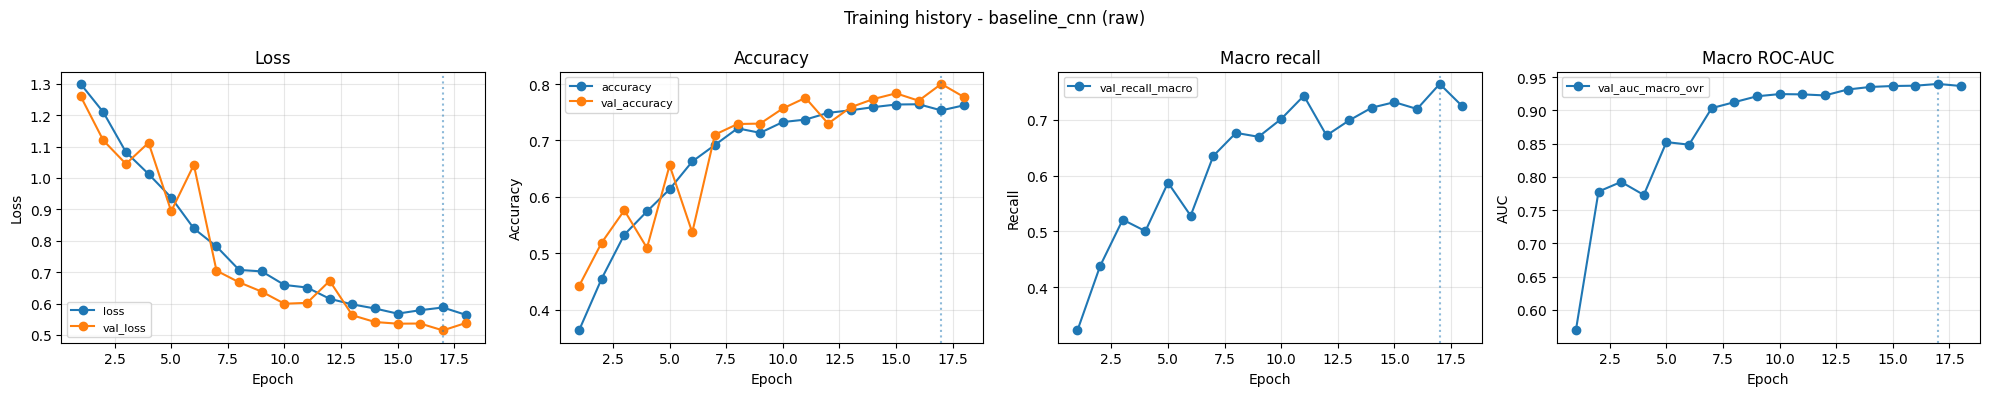

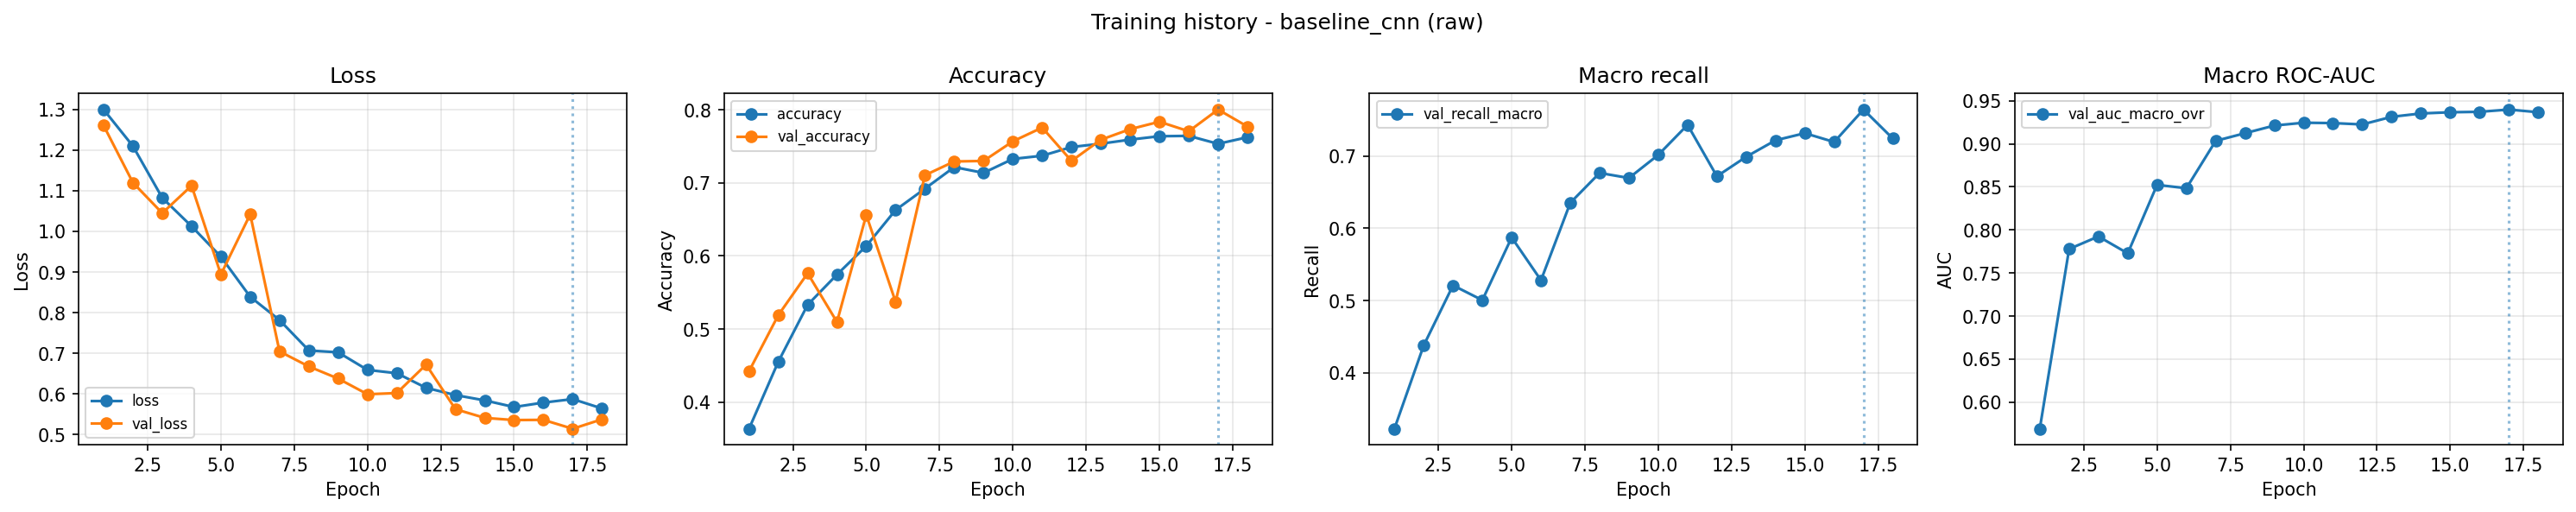

[OK] Training finished
model_name      : baseline_cnn
data_variant    : raw
best_model_path : /content/CXR/data/interim/models/baseline_cnn_raw/best_model.keras
last_model_path : /content/CXR/data/interim/models/baseline_cnn_raw/last_model.keras
history_csv     : /content/CXR/data/interim/models/baseline_cnn_raw/history.csv
history_png     : /content/CXR/data/interim/models/baseline_cnn_raw/training_history.png
===== EVALUATION ===== baseline_cnn
model_path   : /content/CXR/data/interim/models/baseline_cnn_raw/best_model.keras
split_dir    : /content/CXR/data/interim/splits
data_root    : /content/CXR/data/raw
data_variant : raw
out_dir      : /content/CXR/data/interim/models/baseline_cnn_raw
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.7858 - loss: 0.5088

Metrics
------------------------------------------------------------------------
loss                : 0.508782
accuracy            : 0.785818
recall_macro        : 0.745044
f1_macro            : 0.745565
roc_auc_macro_ovr

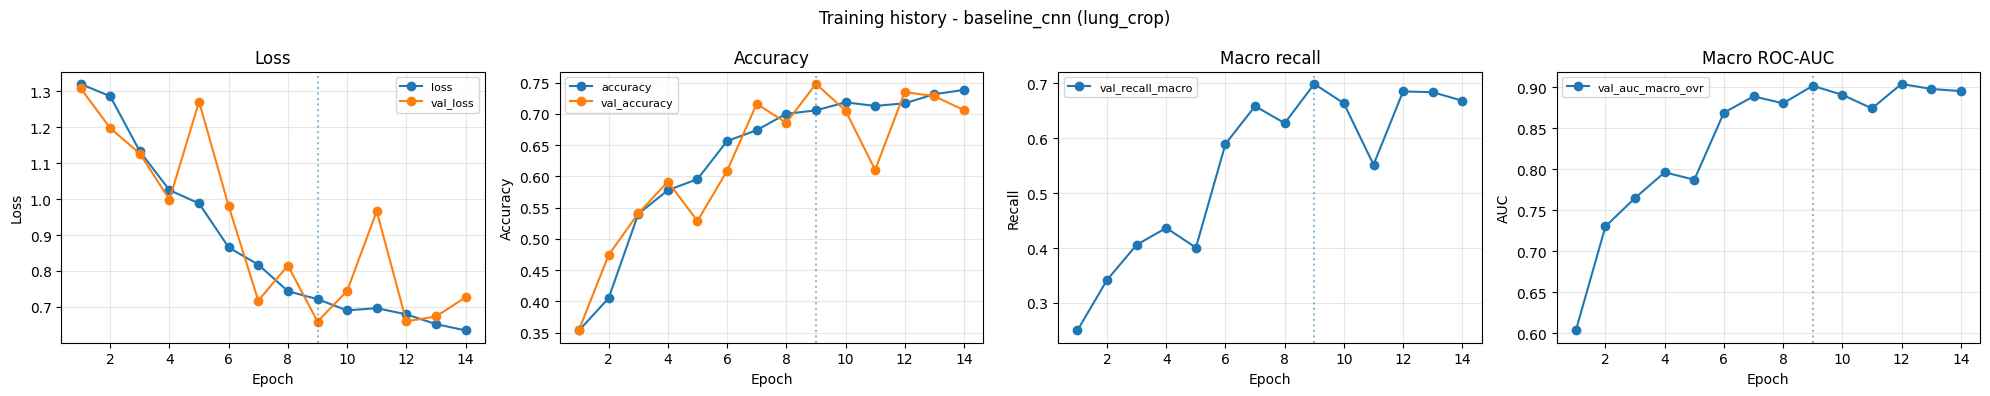

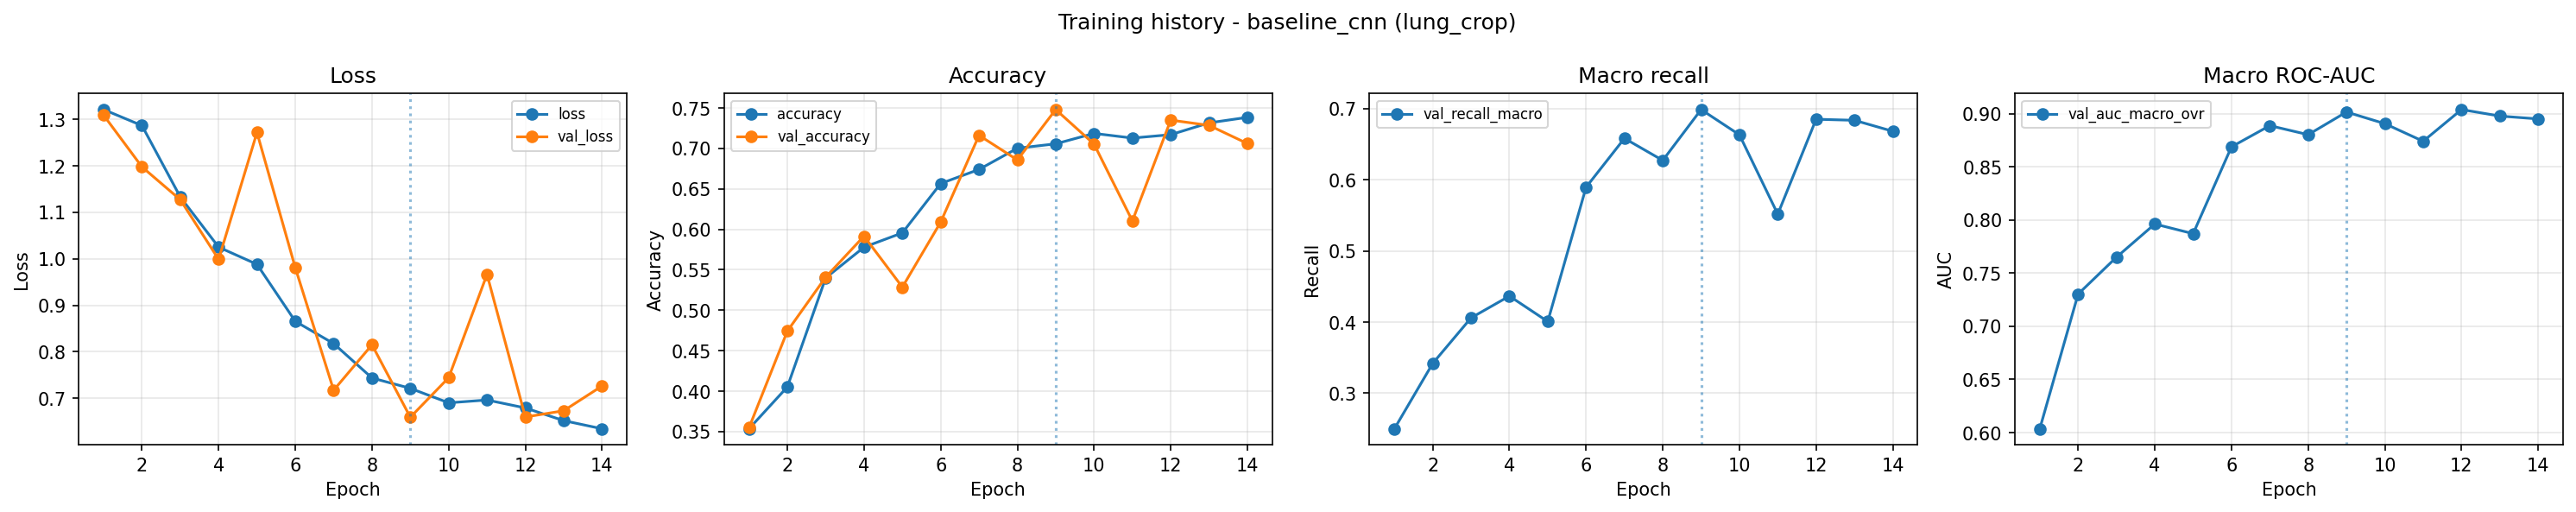

[OK] Training finished
model_name      : baseline_cnn
data_variant    : lung_crop
best_model_path : /content/CXR/data/interim/models/baseline_cnn_lung_crop/best_model.keras
last_model_path : /content/CXR/data/interim/models/baseline_cnn_lung_crop/last_model.keras
history_csv     : /content/CXR/data/interim/models/baseline_cnn_lung_crop/history.csv
history_png     : /content/CXR/data/interim/models/baseline_cnn_lung_crop/training_history.png
===== EVALUATION ===== baseline_cnn
model_path   : /content/CXR/data/interim/models/baseline_cnn_lung_crop/best_model.keras
split_dir    : /content/CXR/data/interim/splits
data_root    : /content/CXR/data/interim/segmentation/lung_crop
data_variant : lung_crop
out_dir      : /content/CXR/data/interim/models/baseline_cnn_lung_crop
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7583 - loss: 0.6274

Metrics
------------------------------------------------------------------------
loss                : 0.627450
accuracy            : 0.758321
recal

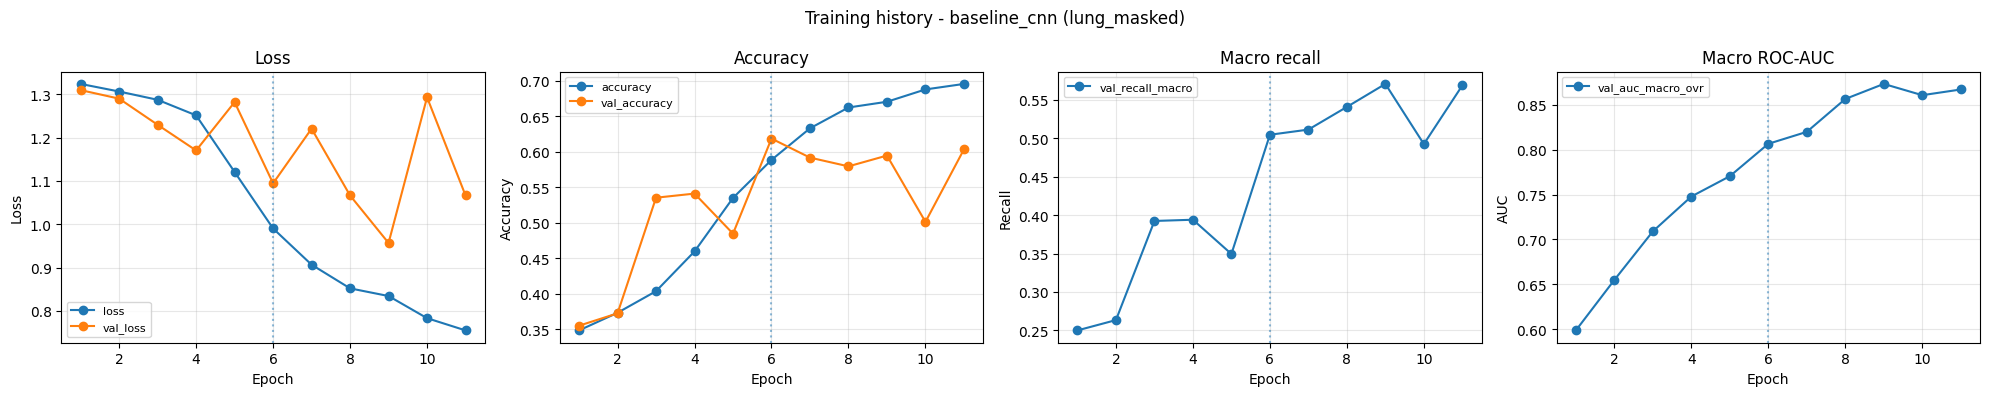

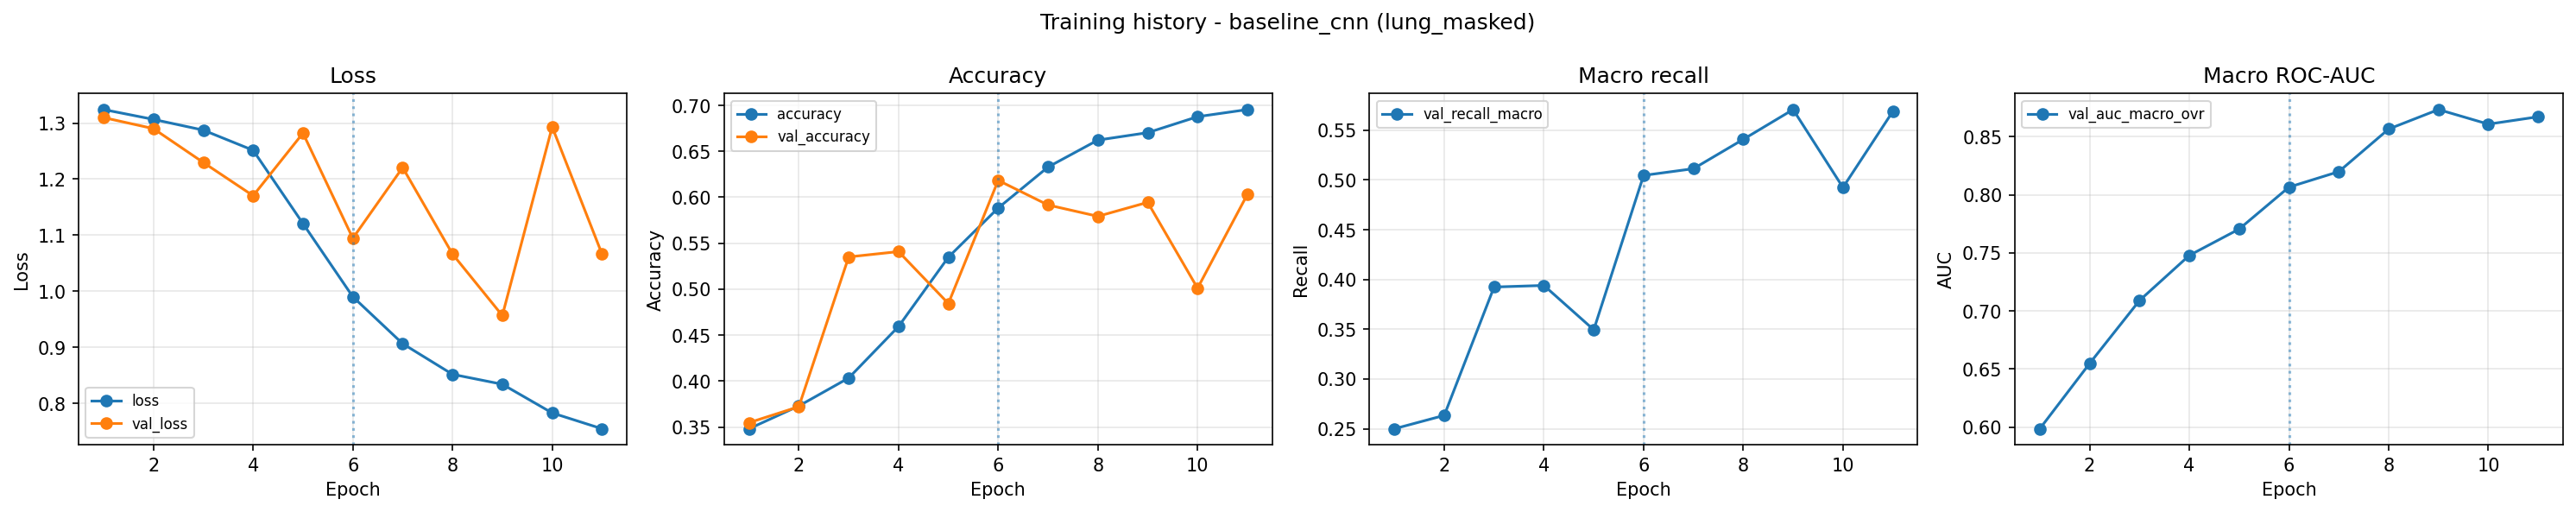

[OK] Training finished
model_name      : baseline_cnn
data_variant    : lung_masked
best_model_path : /content/CXR/data/interim/models/baseline_cnn_lung_masked/best_model.keras
last_model_path : /content/CXR/data/interim/models/baseline_cnn_lung_masked/last_model.keras
history_csv     : /content/CXR/data/interim/models/baseline_cnn_lung_masked/history.csv
history_png     : /content/CXR/data/interim/models/baseline_cnn_lung_masked/training_history.png
===== EVALUATION ===== baseline_cnn
model_path   : /content/CXR/data/interim/models/baseline_cnn_lung_masked/best_model.keras
split_dir    : /content/CXR/data/interim/splits
data_root    : /content/CXR/data/interim/segmentation/lung_masked
data_variant : lung_masked
out_dir      : /content/CXR/data/interim/models/baseline_cnn_lung_masked
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6129 - loss: 1.0945

Metrics
------------------------------------------------------------------------
loss                : 1.094535
accuracy          

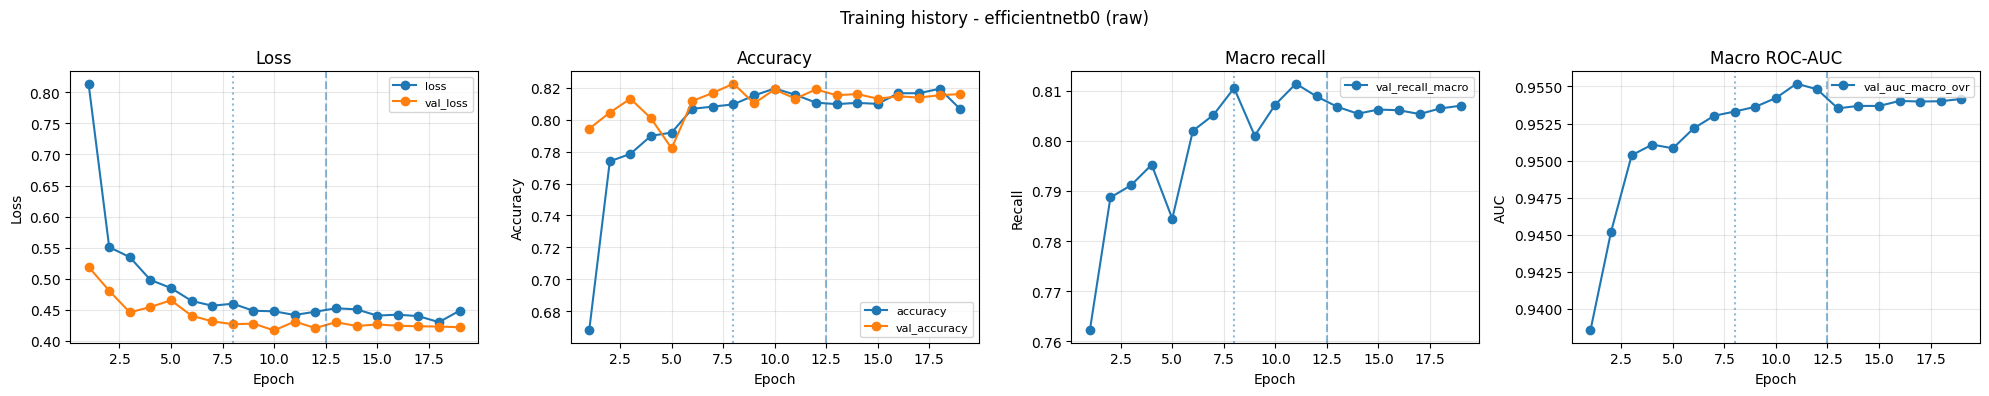

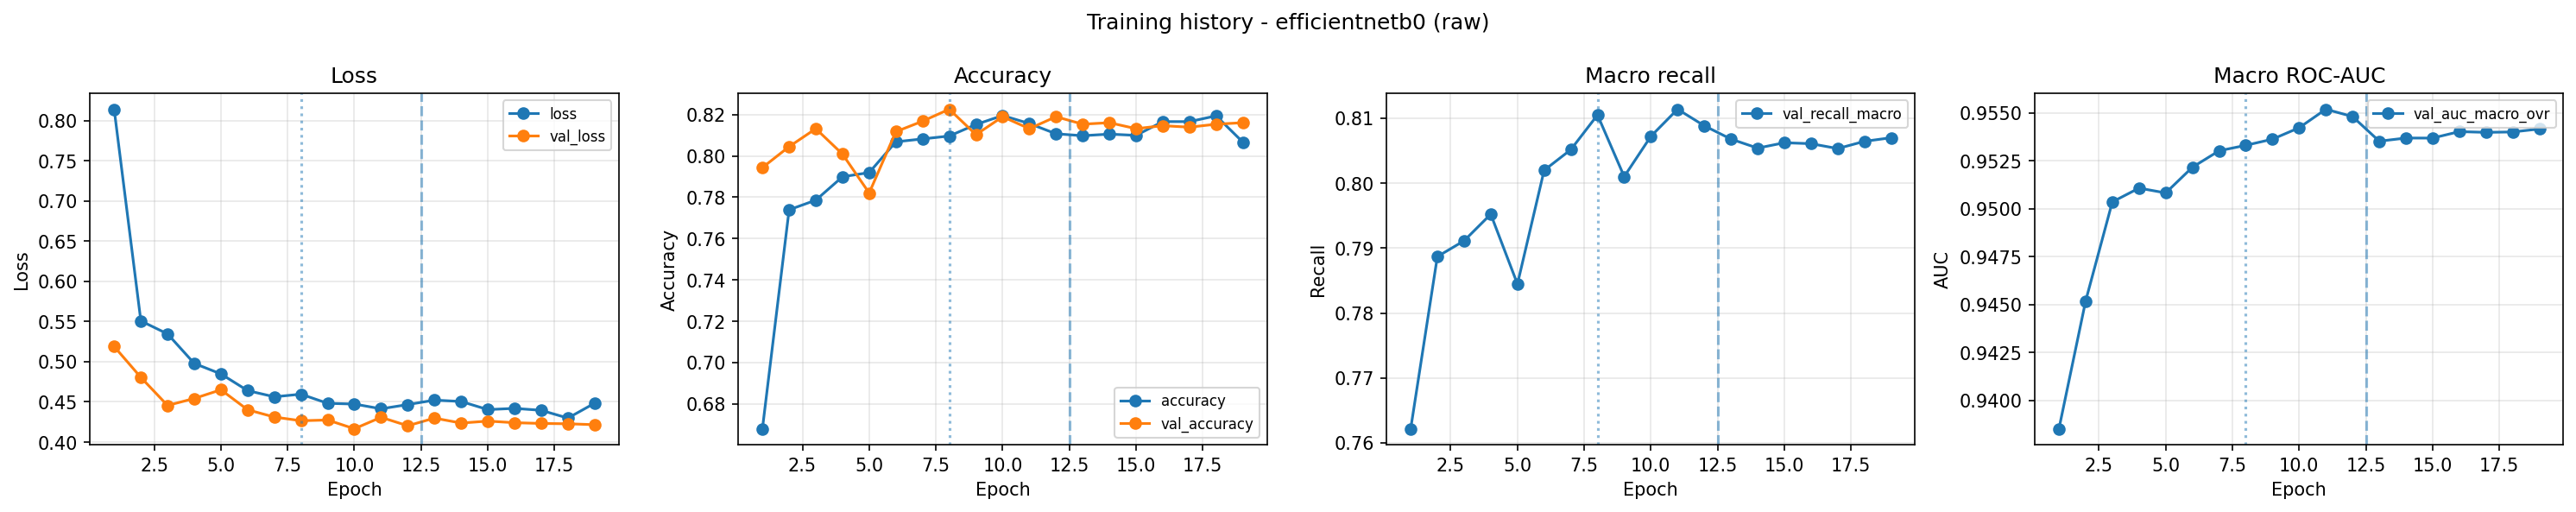

[OK] Training finished
model_name      : efficientnetb0
data_variant    : raw
best_model_path : /content/CXR/data/interim/models/efficientnetb0_raw/best_model.keras
last_model_path : /content/CXR/data/interim/models/efficientnetb0_raw/last_model.keras
history_csv     : /content/CXR/data/interim/models/efficientnetb0_raw/history.csv
history_png     : /content/CXR/data/interim/models/efficientnetb0_raw/training_history.png
===== EVALUATION ===== efficientnetb0
model_path   : /content/CXR/data/interim/models/efficientnetb0_raw/best_model.keras
split_dir    : /content/CXR/data/interim/splits
data_root    : /content/CXR/data/raw
data_variant : raw
out_dir      : /content/CXR/data/interim/models/efficientnetb0_raw
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8104 - loss: 0.4328

Metrics
------------------------------------------------------------------------
loss                : 0.432802
accuracy            : 0.810420
recall_macro        : 0.807515
f1_macro            : 0.806506
roc

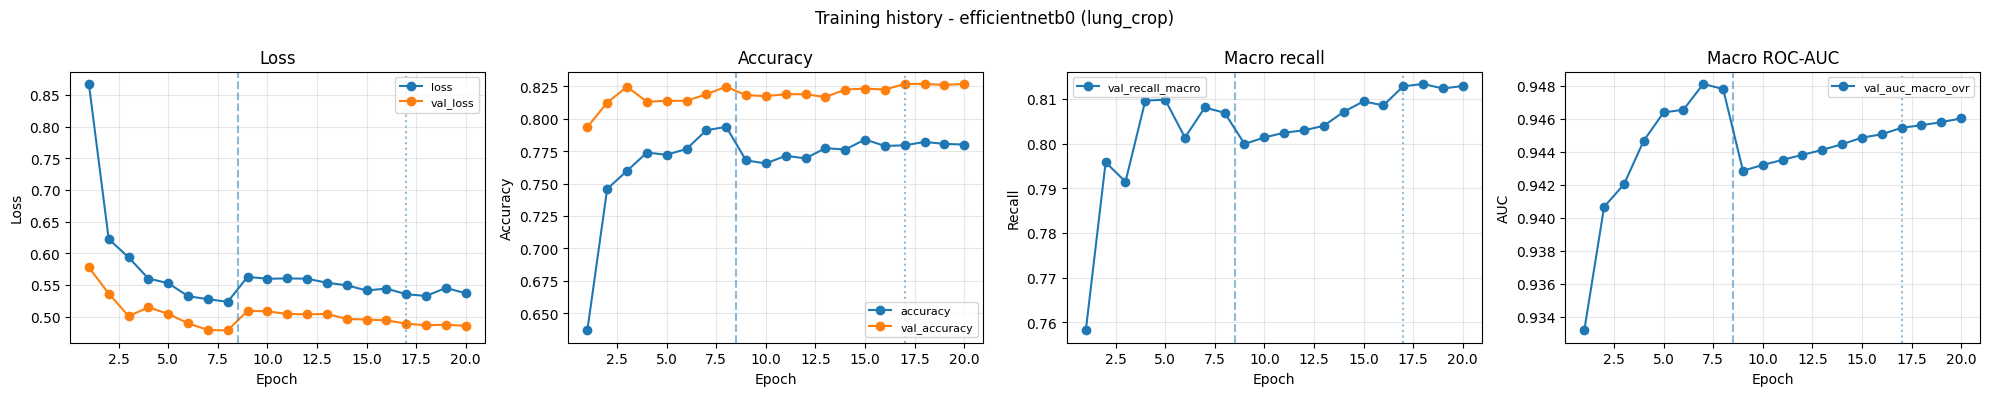

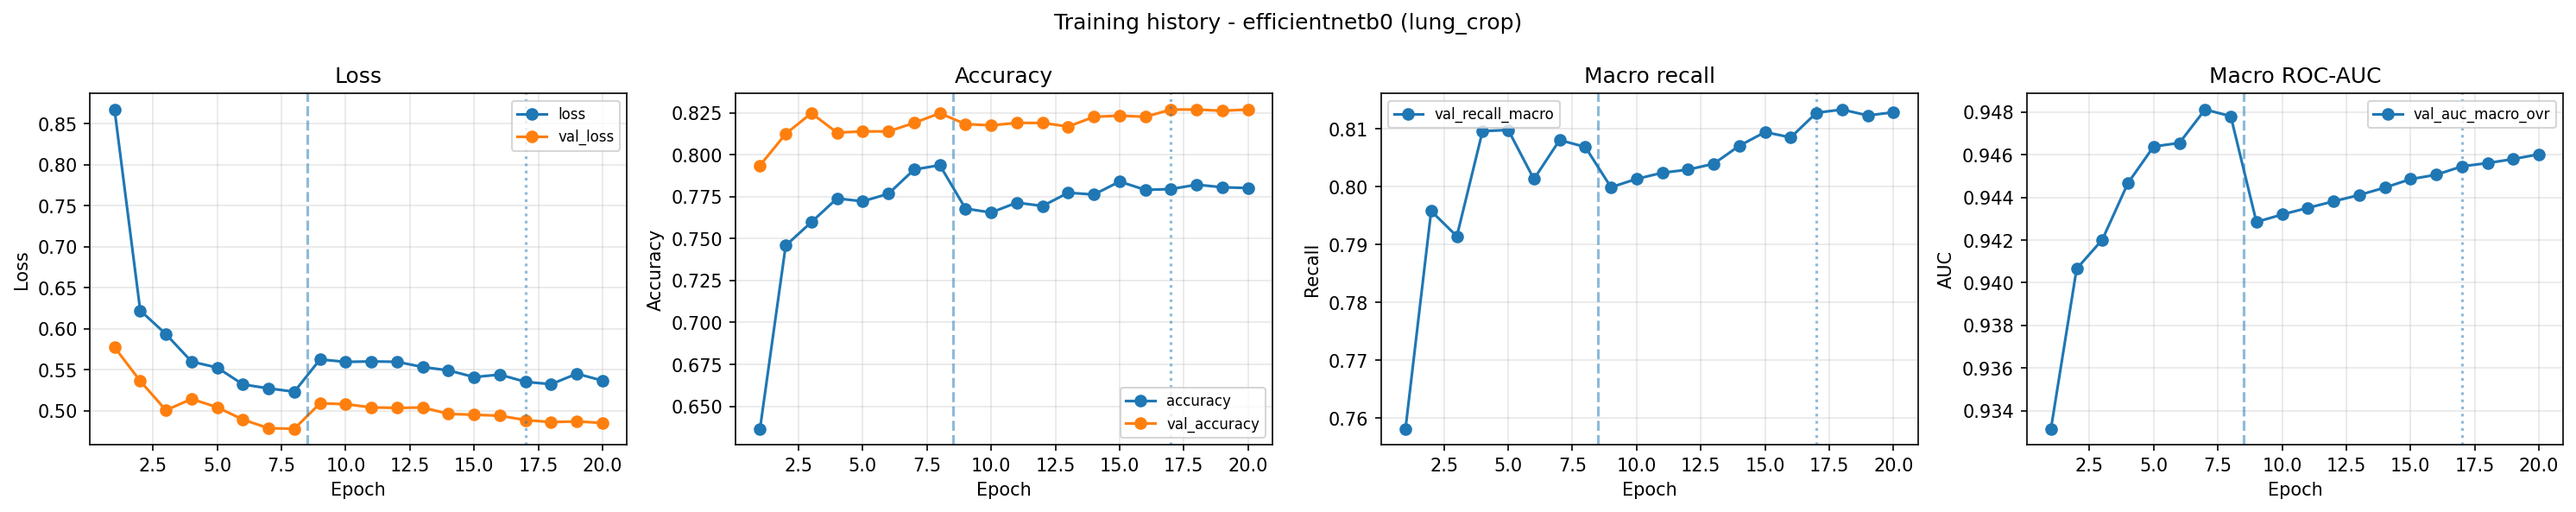

[OK] Training finished
model_name      : efficientnetb0
data_variant    : lung_crop
best_model_path : /content/CXR/data/interim/models/efficientnetb0_lung_crop/best_model.keras
last_model_path : /content/CXR/data/interim/models/efficientnetb0_lung_crop/last_model.keras
history_csv     : /content/CXR/data/interim/models/efficientnetb0_lung_crop/history.csv
history_png     : /content/CXR/data/interim/models/efficientnetb0_lung_crop/training_history.png
===== EVALUATION ===== efficientnetb0
model_path   : /content/CXR/data/interim/models/efficientnetb0_lung_crop/best_model.keras
split_dir    : /content/CXR/data/interim/splits
data_root    : /content/CXR/data/interim/segmentation/lung_crop
data_variant : lung_crop
out_dir      : /content/CXR/data/interim/models/efficientnetb0_lung_crop
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 491ms/step - accuracy: 0.7974 - loss: 0.4993

Metrics
------------------------------------------------------------------------
loss                : 0.499280
accuracy          

: 

In [22]:
model_results_df = run_training_pipeline(
    split_dir=SPLITS_DIR,
    run_configs=MODEL_RUN_CONFIGS,
    run_full_retrain=RUN_FULL_RETRAIN,
    models_dir=MODELS_DIR,
)

print("[OK] Pipeline training lepes kesz.")
print("\n[CHECK] model x variant:")
print(model_results_df.groupby(["model", "data_variant"]).size())

print("\n[CHECK] models:")
print(model_results_df["model"].unique())

print("\n[CHECK] variants:")
print(model_results_df["data_variant"].unique())


## 3.5 Vegso Osszefuzes es Leaderboard

Itt epul fel a vegso `comparison_df`, deduplikalva `model + data_variant` kulcs alapjan.

A blokk egyszerre menti a leaderboard artefaktumokat is.

In [ ]:
comparison_df, FINAL_OUT_DIR = build_final_comparison(
    model_results_df=model_results_df,
    final_comparison_name=FINAL_COMPARISON_NAME,
    models_dir=MODELS_DIR,
)

print_pipeline_leaderboard(comparison_df)
display(comparison_df)


## 3.6 Vegso Vizualizacios Pipeline

A vegso `comparison_df` alapjan keszulnek a standard osszehasonlito abra-csomagok:

- osszesitett metric chartok,
- training gorbek,
- epoch-os osszehasonlitasok.

In [ ]:
generate_final_plots(comparison_df, FINAL_OUT_DIR, show=True)
print("[OK] Final comparison plots saved to:", FINAL_OUT_DIR)


## 3.7 Explainability Pipeline

Ebben a lepesben fut a Grad-CAM + saliency osszehasonlitas.

Celja, hogy vizualisan is ellenorizheto legyen, mit tanultak a modellek kulonbozo adatformakon.

In [ ]:
explainability_summary = run_compare_explainability(
    model_names=["baseline_cnn", "efficientnetb0", "resnet50", "vgg16"],
    data_variants=DATA_VARIANTS,
    split_dir=SPLITS_DIR,
    out_dir=Path(OUTPUT_DIR) / "figures" / "project_final_explainability",
    n_examples=6,
    include_saliency=True,
    show=True,
    skip_existing=False,
)
explainability_summary


## 3.8 Best Model Kivalasztas

A blokk kivalasztja a legjobb modellt variansonkent es modellenkent a macro-F1 alapjan.

Ez a riportolas es deployment priorizalas alapja.

In [ ]:
from pathlib import Path

from IPython.display import Image, display

best_by_variant, best_by_model = report_best_models(comparison_df, FINAL_OUT_DIR, show_plots=True)

print("Best by variant:")
display(best_by_variant)

print("Best by model:")
display(best_by_model)

for rel in ("best_models_plots/best_by_variant_metrics_row.png", "best_models_plots/best_by_model_metrics_row.png"):
    p = FINAL_OUT_DIR / rel
    if p.exists():
        display(Image(filename=str(p)))


# 4. Zárás

Colab futas eseten a notebook mentesi kerest kuld, hogy a pipeline eredmenyei biztosan megmaradjanak.


In [ ]:
from pathlib import Path
import shutil

from src.config import IS_COLAB, OUTPUT_DIR, LOGS_DIR, GDRIVE_OUTPUT, ensure_dir

if IS_COLAB:
    gdrive_out = ensure_dir(GDRIVE_OUTPUT)
    output_src = Path(OUTPUT_DIR)
    logs_src = Path(LOGS_DIR)

    output_dst = gdrive_out / "outputs"
    logs_dst = gdrive_out / "logs"

    if output_src.exists():
        shutil.copytree(output_src, output_dst, dirs_exist_ok=True)
        print("[OK] OUTPUT_DIR copied to:", output_dst)
    else:
        print("[WARN] OUTPUT_DIR does not exist:", output_src)

    if logs_src.exists():
        shutil.copytree(logs_src, logs_dst, dirs_exist_ok=True)
        print("[OK] LOGS_DIR copied to:", logs_dst)
    else:
        print("[WARN] LOGS_DIR does not exist:", logs_src)
else:
    print("[INFO] Not running in Colab, skip Drive sync.")

try:
    from google.colab import _message
    _message.blocking_request("request_save", timeout_sec=10)
    print("Notebook save requested.")
except Exception as e:
    print("[WARN] Notebook save request failed or not running in Colab:", e)
